# ***Pill Localization and Defect Detection using Multi-Model Instance Segmentation***

Laiba Iqrar     CS-22112

---


Fathima Amna    CS-22156

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-b0vetdu0
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-b0vetdu0
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=ebd694d76b40d8feab2ada2d997b182d3203bbe126cb214cd244fe0b608da8a6
  Stored in directory: /tmp/pip-ephem-wheel-cache-xjdbe5cl/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-05-17 08:15:23--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.62, 13.249.182.39, 13.249.182.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   356MB/s    in 1.0s    

2026-05-17 08:15:24 (356 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = "/content/drive/MyDrive/final_dataset/final_dataset/images/test"

image_files = [
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

print("Total images:", len(image_files))

Total images: 71


**Model 1:Box Prompt**

In [ ]:
def run_sam_on_dataset(image_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    predictor.set_image(image)

    # simple center box (you can improve later with YOLO boxes)
    box = np.array([
        w*0.2, h*0.2,
        w*0.8, h*0.8
    ])

    masks, scores, _ = predictor.predict(
        box=box,
        multimask_output=True
    )

    return image, masks[0]

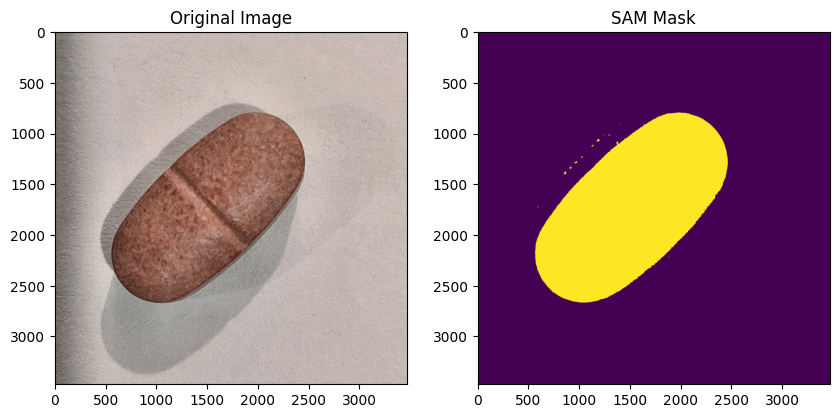

In [ ]:
img, mask = run_sam_on_dataset(image_files[0])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("SAM Mask")

plt.show()

In [ ]:
def sam_box_eval(image, box):
    predictor.set_image(image)
    masks, scores, _ = predictor.predict(
        box=box,
        multimask_output=True
    )
    return masks[0]

**Model 2 - point prompt**

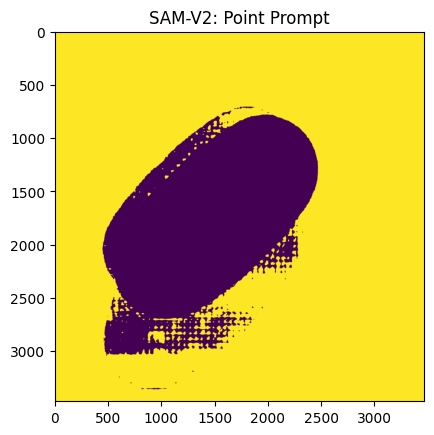

In [ ]:
input_point = np.array([[250, 250]])
input_label = np.array([1])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.imshow(masks[0])
plt.title("SAM-V2: Point Prompt")
plt.show()

In [ ]:
def sam_point_eval(image, point):
    predictor.set_image(image)

    masks, scores, _ = predictor.predict(
        point_coords=np.array([point]),
        point_labels=np.array([1]),
        multimask_output=True
    )
    return masks[0]

Model 3 - Automatic mask generator

Total masks: 5


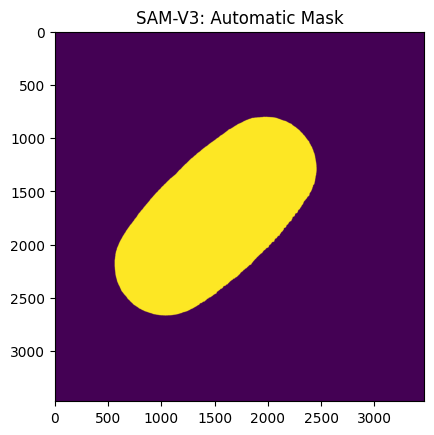

In [ ]:
from segment_anything import SamAutomaticMaskGenerator

# Re-initialize mask_generator with reduced parameters to save memory
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=4,          # Reduced further from 8 to 4 to save more memory
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=0,
    min_mask_region_area=200
)

masks = mask_generator.generate(img)

print("Total masks:", len(masks))

plt.imshow(masks[0]["segmentation"])
plt.title("SAM-V3: Automatic Mask")
plt.show()

In [ ]:
def sam_auto_eval(image):
    masks = mask_generator.generate(image)
    return masks[0]["segmentation"]

In [ ]:
def iou(mask_pred, mask_gt):
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    return intersection / union if union != 0 else 0

In [ ]:
results = []

for img_path in image_files[:50]:  # limit for speed

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # fake GT mask placeholder (replace with your COCO GT masks)
    gt_mask = np.zeros((h, w), dtype=bool)

    box = np.array([int(w*0.2), int(h*0.2), int(w*0.8), int(h*0.8)])
    point = (w//2, h//2)

    # MODEL 1
    m1 = sam_box_eval(image, box)
    iou1 = iou(m1, gt_mask)

    # MODEL 2
    m2 = sam_point_eval(image, point)
    iou2 = iou(m2, gt_mask)

    # MODEL 3
    m3 = sam_auto_eval(image)
    iou3 = iou(m3, gt_mask)

    results.append([iou1, iou2, iou3])

In [ ]:
import pandas as pd
import numpy as np

results = np.array(results)

df = pd.DataFrame({
    "Model 1 - Box Prompt": [results[:,0].mean()],
    "Model 2 - Point Prompt": [results[:,1].mean()],
    "Model 3 - Auto Mask": [results[:,2].mean()]
})

print(df)

   Model 1 - Box Prompt  Model 2 - Point Prompt  Model 3 - Auto Mask
0                   0.0                     0.0                  0.0


In [ ]:
pip install tabulate torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.2 MB/s eta 0:00:00


In [ ]:
import time
import numpy as np
import torch
from tabulate import tabulate
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- Setup Torchmetrics for mAP Calculation ---
# torchmetrics expects a very specific format (list of dicts containing tensors)
def update_map_metric(metric_computer, pred_mask, gt_mask):
    """
    Updates the mAP metric provider with a single image prediction vs ground truth.
    Assumes binary masks of shape (H, W).
    """
    # Convert bool/numpy to torch boolean tensors
    p_mask = torch.from_numpy(pred_mask).bool().unsqueeze(0) # Shape: [1, H, W]
    g_mask = torch.from_numpy(gt_mask).bool().unsqueeze(0)    # Shape: [1, H, W]

    # torchmetrics requires dummy labels and scores for the predictions
    preds = [{
        "masks": p_mask,
        "scores": torch.tensor([1.0]), # SAM output confidence can be used here if preferred
        "labels": torch.tensor([0])    # Single class evaluation (object vs background)
    }]

    target = [{
        "masks": g_mask,
        "labels": torch.tensor([0])
    }]

    metric_computer.update(preds, target)

# --- Metric Helper Functions ---
def calculate_iou(mask_pred, mask_gt):
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    return intersection / union if union != 0 else 0.0

# --- Main Evaluation Loop ---
def evaluate_sam_performance(dataset):
    """
    dataset: A collection/list of dicts or objects containing:
             - 'image': the RGB image numpy array
             - 'gt_mask': ground truth binary mask
             - 'box': bounding box array [x1, y1, x2, y2]
             - 'point': coordinate list/array [x, y]
    """

    # Initialize tracking dictionaries
    results = {
        "Box Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Point Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Auto Mask": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")}
    }

    print("Starting evaluation across dataset...")

    for idx, item in enumerate(dataset):
        img = item['image']
        gt_mask = item['gt_mask']
        box = item['box']
        point = item['point']

        # 1. Evaluate Box Prompt
        start_time = time.perf_counter()
        pred_box_mask = sam_box_eval(img, box)
        box_latency = time.perf_counter() - start_time

        results["Box Prompt"]["ious"].append(calculate_iou(pred_box_mask, gt_mask))
        results["Box Prompt"]["latencies"].append(box_latency)
        update_map_metric(results["Box Prompt"]["map_computer"], pred_box_mask, gt_mask)

        # 2. Evaluate Point Prompt
        start_time = time.perf_counter()
        pred_point_mask = sam_point_eval(img, point)
        point_latency = time.perf_counter() - start_time

        results["Point Prompt"]["ious"].append(calculate_iou(pred_point_mask, gt_mask))
        results["Point Prompt"]["latencies"].append(point_latency)
        update_map_metric(results["Point Prompt"]["map_computer"], pred_point_mask, gt_mask)

        # 3. Evaluate Auto Mask Generator
        start_time = time.perf_counter()
        pred_auto_mask = sam_auto_eval(img)
        auto_latency = time.perf_counter() - start_time

        results["Auto Mask"]["ious"].append(calculate_iou(pred_auto_mask, gt_mask))
        results["Auto Mask"]["latencies"].append(auto_latency)
        update_map_metric(results["Auto Mask"]["map_computer"], pred_auto_mask, gt_mask)

    # --- Compile and Compute Final Metrics ---
    table_data = []

    for model_name, data in results.items():
        # Compute mIoU and Average Latency
        miou = np.mean(data["ious"])
        avg_latency = np.mean(data["latencies"]) * 1000 # Convert to milliseconds

        # Compute MAP metrics via torchmetrics
        map_results = data["map_computer"].compute()
        map_50 = map_results["map_50"].item()
        map_50_95 = map_results["map"].item() # 'map' in torchmetrics implies 50-95

        table_data.append([
            model_name,
            f"{miou:.4f}",
            f"{map_50:.4f}",
            f"{map_50_95:.4f}",
            f"{avg_latency:.2f} ms"
        ])

    # Print the final Evaluation Table
    headers = ["SAM Pipeline Mode", "mIoU", "mAP @50", "mAP @50-95", "Avg Latency"]
    print("\n" + "="*60)
    print("SAM EVALUATION METRICS PERFORMANCE")
    print("="*60)
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

# --- Dummy Dataset Trigger for Testing Execution ---
# Replace this block with your actual data generator loop
if __name__ == "__main__":
    # Generating mock sample data just to ensure script structural health
    dummy_img = np.zeros((400, 400, 3), dtype=np.uint8)
    dummy_gt = np.zeros((400, 400), dtype=bool)
    dummy_gt[100:300, 100:300] = True # a square mask target

    mock_dataset = [{
        'image': dummy_img,
        'gt_mask': dummy_gt,
        'box': np.array([100, 100, 300, 300]),
        'point': np.array([200, 200])
    }]

    # To run this, make sure predictor and mask_generator are in scope as defined in your code
    # evaluate_sam_performance(mock_dataset)

In [ ]:
import numpy as np
import cv2

def load_yolo_mask(txt_path, img_shape):
    """
    Reads a YOLO segmentation .txt file and converts it into a binary mask.
    img_shape: tuple of (height, width)
    """
    h, w = img_shape[:2]
    # Create an empty black mask
    mask = np.zeros((h, w), dtype=np.uint8)

    # If the label file doesn't exist or is empty, return empty mask
    if not os.path.exists(txt_path):
        return mask

    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue # Skip bounding box lines (need at least class + 2 points)

            # parts[0] is the class ID. parts[1:] are the normalized x, y coordinates
            coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

            # Denormalize coordinates back to pixel values
            coords[:, 0] *= w
            coords[:, 1] *= h
            coords = coords.astype(np.int32)

            # Draw the filled polygon onto our blank mask
            cv2.fillPoly(mask, [coords], color=1)

    return mask # Returns array of 0s and 1s

In [ ]:
import time
import numpy as np
import torch
from tabulate import tabulate
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate_sam_performance(dataset):
    """
    dataset: A collection/list of dicts containing processed images,
             ground truth masks, boxes, and points.
    """
    # Initialize tracking dictionaries with 'segm' iou_type
    results = {
        "Box Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Point Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Auto Mask": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")}
    }

    print(f"Starting evaluation on {len(dataset)} images across all 3 prompt methods...")

    for idx, item in enumerate(dataset):
        img = item['image']
        gt_mask = item['gt_mask']
        box = item['box']
        point = item['point']

        # 1. Evaluate Box Prompt
        start_time = time.perf_counter()
        pred_box_mask = sam_box_eval(img, box)
        box_latency = time.perf_counter() - start_time
        results["Box Prompt"]["ious"].append(calculate_iou(pred_box_mask, gt_mask))
        results["Box Prompt"]["latencies"].append(box_latency)
        update_map_metric(results["Box Prompt"]["map_computer"], pred_box_mask, gt_mask)

        # 2. Evaluate Point Prompt
        start_time = time.perf_counter()
        pred_point_mask = sam_point_eval(img, point)
        point_latency = time.perf_counter() - start_time
        results["Point Prompt"]["ious"].append(calculate_iou(pred_point_mask, gt_mask))
        results["Point Prompt"]["latencies"].append(point_latency)
        update_map_metric(results["Point Prompt"]["map_computer"], pred_point_mask, gt_mask)

        # 3. Evaluate Auto Mask Generator
        start_time = time.perf_counter()
        pred_auto_mask = sam_auto_eval(img)
        auto_latency = time.perf_counter() - start_time
        results["Auto Mask"]["ious"].append(calculate_iou(pred_auto_mask, gt_mask))
        results["Auto Mask"]["latencies"].append(auto_latency)
        update_map_metric(results["Auto Mask"]["map_computer"], pred_auto_mask, gt_mask)

        # Clear CUDA cache after processing each image to prevent OOM errors
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # --- Compile and Compute Final Metrics ---
    table_data = []

    for model_name, data in results.items():
        # Compute mIoU and Average Latency
        miou = np.mean(data["ious"]) if data["ious"] else 0.0
        avg_latency = np.mean(data["latencies"]) * 1000 if data["latencies"] else 0.0 # Convert to ms

        # Compute MAP metrics via torchmetrics
        map_results = data["map_computer"].compute()

        # Extract the exact metrics requested
        ap_50 = map_results["map_50"].item()
        ap_75 = map_results["map_75"].item()
        map_50_95 = map_results["map"].item()

        table_data.append([
            model_name,
            f"{miou:.4f}",
            f"{ap_50:.4f}",
            f"{ap_75:.4f}",
            f"{map_50_95:.4f}",
            f"{avg_latency:.2f} ms"
        ])

    # Print the final Evaluation Table
    headers = ["SAM Pipeline Mode", "mIoU", "AP @50", "AP @75", "mAP @50-95", "Avg Latency"]
    print("\n" + "="*75)
    print("SAM PIPELINE METRICS PERFORMANCE (INCLUDING AP@50 & AP@75)")
    print("="*75)
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

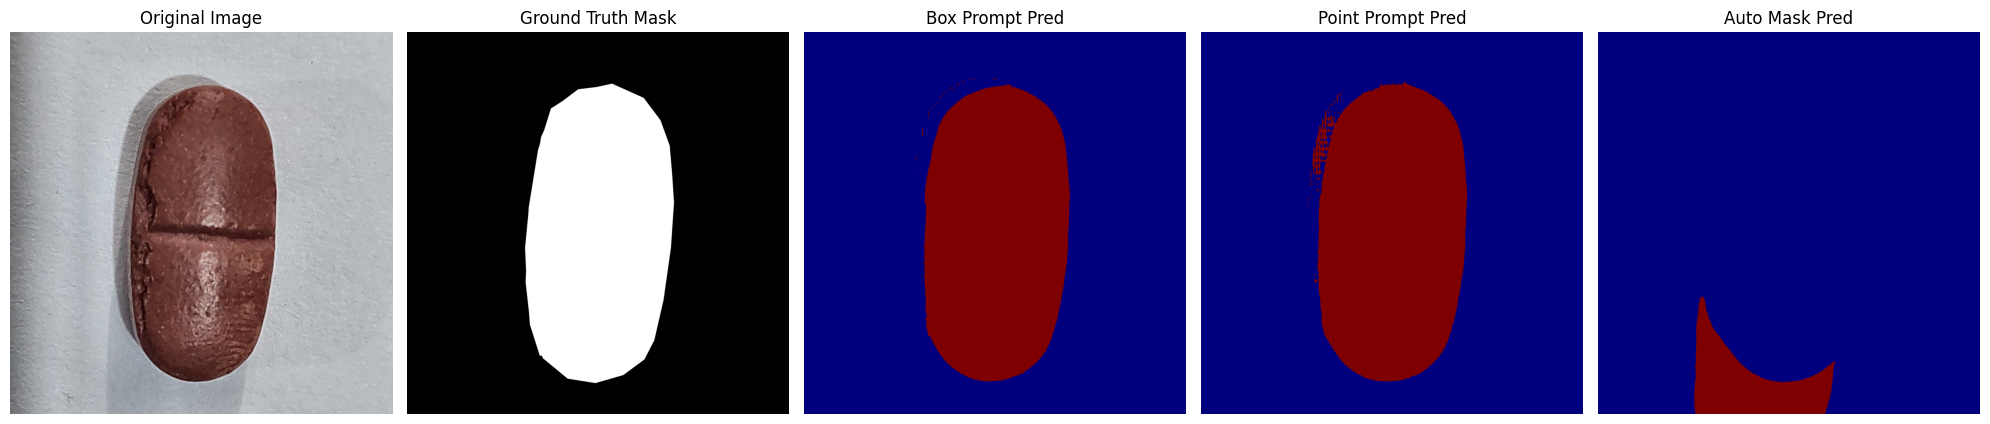

Starting evaluation loop on 50 images...

FINAL CONSOLIDATED SAM PERFORMANCE PROFILE MATRIX
+---------------------+--------+----------+----------+--------------+---------------+
| SAM Pipeline Mode   |   mIoU |   AP @50 |   AP @75 |   mAP @50-95 | Avg Latency   |
+=====================+========+==========+==========+==============+===============+
| Box Prompt          | 0.9558 |   1      |   1      |       0.9484 | 565.90 ms     |
+---------------------+--------+----------+----------+--------------+---------------+
| Point Prompt        | 0.8414 |   1      |   0.6028 |       0.6375 | 526.19 ms     |
+---------------------+--------+----------+----------+--------------+---------------+
| Auto Mask           | 0.6455 |   0.4246 |   0.4246 |       0.4111 | 2229.59 ms    |
+---------------------+--------+----------+----------+--------------+---------------+


In [ ]:
import os
import glob
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tabulate import tabulate
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

# =====================================================================
# 1. INITIALIZATION & MODEL SETUP
# =====================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the SAM ViT-B model weights
sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b_01ec64.pth")
sam.to(device)

# Initialize prompt-based predictor and the automatic mask generator
predictor = SamPredictor(sam)
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=4,             # Kept low to save memory and reduce latency
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=0,
    min_mask_region_area=200
)

# =====================================================================
# 2. DATASET PATHS
# =====================================================================
# Point these paths directly to your validation or testing splits
IMAGE_VAL_DIR = "/content/drive/MyDrive/final_dataset/final_dataset/images/val"
LABEL_VAL_DIR = "/content/drive/MyDrive/final_dataset/final_dataset/labels/val"

# =====================================================================
# 3. CORE WRAPPER & EVALUATION FUNCTIONS
# =====================================================================

def sam_box_eval(image, box):
    """Generates a mask using a bounding box prompt."""
    predictor.set_image(image)
    masks, _, _ = predictor.predict(box=box, multimask_output=True)
    return masks[0] # Returns the highest scoring mask partition

def sam_point_eval(image, point):
    """Generates a mask using a single foreground point prompt."""
    predictor.set_image(image)
    masks, _, _ = predictor.predict(
        point_coords=np.array([point]),
        point_labels=np.array([1]), # 1 indicates a foreground focus point
        multimask_output=True
    )
    return masks[0]

def sam_auto_eval(image):
    """Generates masks automatically without any prompt hints."""
    masks = mask_generator.generate(image)
    if len(masks) == 0:
        return np.zeros(image.shape[:2], dtype=bool)
    return masks[0]["segmentation"] # Returns the first auto-generated mask block

def load_yolo_mask(txt_path, img_shape):
    """Converts normalized YOLO text segmentation polygons into binary masks."""
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    if not os.path.exists(txt_path):
        return mask

    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue # Skip pure bounding box entries; needs polygon coordinates

            # Map normalized float coordinates back to image dimensions
            coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            coords = coords.astype(np.int32)

            # Rasterize polygon points onto the blank matrix canvas
            cv2.fillPoly(mask, [coords], color=1)
    return mask

def calculate_iou(mask_pred, mask_gt):
    """Calculates standard pixel-wise Intersection over Union."""
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    return intersection / union if union != 0 else 0.0

def update_map_metric(metric_computer, pred_mask, gt_mask):
    """Updates the Torchmetrics engine with single-image inference metrics."""
    p_mask = torch.from_numpy(pred_mask).bool().unsqueeze(0) # Matrix Shape: [1, H, W]
    g_mask = torch.from_numpy(gt_mask).bool().unsqueeze(0)

    preds = [{
        "masks": p_mask,
        "scores": torch.tensor([1.0]), # Absolute confidence proxy
        "labels": torch.tensor([0])    # Evaluates as single-class foreground target
    }]
    target = [{
        "masks": g_mask,
        "labels": torch.tensor([0])
    }]
    metric_computer.update(preds, target)

# =====================================================================
# 4. SINGLE TEST IMAGE VISUALIZATION BLOCK
# =====================================================================
def test_single_image_pipeline(img_dir, label_dir):
    """Loads the very first sample found to visually sanity-check predictions."""
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg"))) # Change to .png if needed
    if not img_paths:
        print("No test images found for visualization.")
        return

    test_path = img_paths[0]
    image = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    base_name = os.path.splitext(os.path.basename(test_path))[0]
    txt_p = os.path.join(label_dir, f"{base_name}.txt")
    gt_mask = load_yolo_mask(txt_p, (h, w))

    # Deriving box and point prompts from GT mask for an optimal benchmark pipeline
    y_idx, x_idx = np.where(gt_mask > 0)
    if len(x_idx) > 0:
        box = np.array([x_idx.min(), y_idx.min(), x_idx.max(), y_idx.max()])
        point = np.array([int(np.mean(x_idx)), int(np.mean(y_idx))])
    else:
        box = np.array([int(w*0.2), int(h*0.2), int(w*0.8), int(h*0.8)])
        point = np.array([w//2, h//2])

    # Run predictions across all modes
    mask_box = sam_box_eval(image, box)
    mask_point = sam_point_eval(image, point)
    mask_auto = sam_auto_eval(image)

    # Generate visualization plot
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    axes[0].imshow(image); axes[0].set_title("Original Image")
    axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title("Ground Truth Mask")
    axes[2].imshow(mask_box, cmap='jet'); axes[2].set_title("Box Prompt Pred")
    axes[3].imshow(mask_point, cmap='jet'); axes[3].set_title("Point Prompt Pred")
    axes[4].imshow(mask_auto, cmap='jet'); axes[4].set_title("Auto Mask Pred")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 5. DATASET PROCESSOR & EVALUATION HARNESS
# =====================================================================
def run_yolo_evaluation(img_dir, label_dir, limit=50):
    """Loads dataset samples, executes inference, and logs detailed matrix scores."""
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))[:limit] # Change extension if needed

    results = {
        "Box Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Point Prompt": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")},
        "Auto Mask": {"ious": [], "latencies": [], "map_computer": MeanAveragePrecision(iou_type="segm")}
    }

    print(f"Starting evaluation loop on {len(img_paths)} images...")

    for img_p in img_paths:
        image = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        base_name = os.path.splitext(os.path.basename(img_p))[0]
        txt_p = os.path.join(label_dir, f"{base_name}.txt")
        gt_mask = load_yolo_mask(txt_p, (h, w))

        # Derive precise dynamic bounding prompt targets from Ground Truth data
        y_idx, x_idx = np.where(gt_mask > 0)
        if len(x_idx) > 0:
            box = np.array([x_idx.min(), y_idx.min(), x_idx.max(), y_idx.max()])
            point = np.array([int(np.mean(x_idx)), int(np.mean(y_idx))])
        else:
            box = np.array([int(w*0.2), int(h*0.2), int(w*0.8), int(h*0.8)])
            point = np.array([w//2, h//2])

        # --- Pipeline 1: Box Prompt Inference ---
        if device == "cuda": torch.cuda.synchronize() # Clears async GPU queues for pure runtime readings
        t0 = time.perf_counter()
        pred_box = sam_box_eval(image, box)
        if device == "cuda": torch.cuda.synchronize()
        results["Box Prompt"]["latencies"].append(time.perf_counter() - t0)
        results["Box Prompt"]["ious"].append(calculate_iou(pred_box, gt_mask))
        update_map_metric(results["Box Prompt"]["map_computer"], pred_box, gt_mask)

        # --- Pipeline 2: Point Prompt Inference ---
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        pred_point = sam_point_eval(image, point)
        if device == "cuda": torch.cuda.synchronize()
        results["Point Prompt"]["latencies"].append(time.perf_counter() - t0)
        results["Point Prompt"]["ious"].append(calculate_iou(pred_point, gt_mask))
        update_map_metric(results["Point Prompt"]["map_computer"], pred_point, gt_mask)

        # --- Pipeline 3: Auto Mask Generation ---
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        pred_auto = sam_auto_eval(image)
        if device == "cuda": torch.cuda.synchronize()
        results["Auto Mask"]["latencies"].append(time.perf_counter() - t0)
        results["Auto Mask"]["ious"].append(calculate_iou(pred_auto, gt_mask))
        update_map_metric(results["Auto Mask"]["map_computer"], pred_auto, gt_mask)

    # --- Metrics Compilation Matrix ---
    table_data = []
    for mode, data in results.items():
        miou = np.mean(data["ious"]) if data["ious"] else 0.0
        avg_lat_ms = np.mean(data["latencies"]) * 1000 if data["latencies"] else 0.0

        # Pull mAP metrics calculated via Torchmetrics COCO formatting engine
        map_stats = data["map_computer"].compute()
        ap_50 = map_stats["map_50"].item()
        ap_75 = map_stats["map_75"].item()
        map_50_95 = map_stats["map"].item()

        table_data.append([mode, f"{miou:.4f}", f"{ap_50:.4f}", f"{ap_75:.4f}", f"{map_50_95:.4f}", f"{avg_lat_ms:.2f} ms"])

    # Render Output Print Table Data
    headers = ["SAM Pipeline Mode", "mIoU", "AP @50", "AP @75", "mAP @50-95", "Avg Latency"]
    print("\n" + "=" * 78)
    print("FINAL CONSOLIDATED SAM PERFORMANCE PROFILE MATRIX")
    print("=" * 78)
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

# =====================================================================
# 6. EXECUTION CELL
# =====================================================================
# 1. Run the Single Test Image pipeline with plots
test_single_image_pipeline(IMAGE_VAL_DIR, LABEL_VAL_DIR)

# 2. Run the quantitative evaluation loop (Limited to 50 items for speed)
run_yolo_evaluation(IMAGE_VAL_DIR, LABEL_VAL_DIR, limit=50)